# Geospatial Data Processing Pipeline

## Table of Contents
1. [Setup and Imports](#setup)
2. [Apelos Processing](#apelos)
   - [KML to GeoJSON Conversion](#conversion)
   - [Data Cleaning](#cleaning)
3. [Neighborhood Survey](#survey)
   - [Neighborhood Filtering](#filtering)
   - [Map Visualization](#visualization)
   - [Data Export](#export)



## Setup and Imports <a name="setup"></a>


In [11]:
import matplotlib.pyplot as plt
import geopandas as gpd
import geoprocess as geo
geo.__version__

'0.2.0'

## Apelos Processing <a name="apelos"></a>

### KML to GeoJSON Conversion <a name="conversion"></a>

In [12]:
path_apelos = "raw_data/Estado Novo - mapeamento dos apelos-3.kml"
apelos = geo.convert_kml_to_geojson(
    path_apelos,
    "pre-processed_data/apelos_tese.geojson"
)

✅ Success! Converted 'raw_data/Estado Novo - mapeamento dos apelos-3.kml' to 'pre-processed_data/apelos_tese.geojson'



### Data cleaning and exporting
 
In this step, we process the raw "apelos" data to clean up the text descriptions and extract any associated links. 
For each record, we:
1. Use `geo.get_first_url` to extract the first URL from the HTML description, storing it in a new 'Link' column.
2. Use `geo.get_clean_text` to remove HTML tags and links from the 'Description' field, leaving only the visible text.

After cleaning, we export the resulting GeoDataFrame to a new GeoJSON file for further analysis.

In [13]:
for idx, row in apelos.iterrows():
    link = geo.get_first_url(row['Description'])
    clean_desc = geo.get_clean_text(row['Description'])
    apelos.at[idx, 'Link'] = link
    apelos.at[idx, 'Description'] = clean_desc

# Export the processed GeoDataFrame to GeoJSON
# geo.save_geojson_pretty(apelos, "processed_data/apelos__tese_clean.geojson");

# Grouping purple "ab47bc" features

In this step we group all occurencies with Key Color purple "ab47bc".

The first step is to split the databe in two sets: one with only purple features; and others.

For this set with others a new feature is created to represent all purple date. The coordinates shall the be the avarage point, the color shall keep purple, and the links shall be concatened.

---

### 📝 Summary of changes (geoprocess v0.2.0)

This step is backed by new helpers added to the `geoprocess` library (version bumped `0.1.0` → `0.2.0`):

- **`geo.split_by_color(gdf, color)`** → returns `(matching, others)`, separating the purple *apelos coletivos* from the rest.
- **`geo.aggregate_features_by_color(gdf, color, ...)`** → collapses all matching features into **one** feature:
  - geometry = **average point** of the purple features, **keeping the Z (altitude)** coordinate so it stays 3D like the rest of the data (`[lon, lat, z]`);
  - `Color` kept purple; links concatenated.
- **`geo.group_features_by_color(...)`** → convenience wrapper returning `others + group` as a single combined layer.

**Outputs** — two files are produced:

| File | Content |
|------|---------|
| `processed_data/apelos_tese_clean.geojson` | all non-purple features **+ ONE condensed purple entry** (the 97 purple collapsed into a single feature); `Link` concatenated, `Description` written as a **phrase** |
| `processed_data/apelos_coletivos_roxo.geojson` | **all 97 purple features**, exported as-is (no condensing) |

See `CHANGELOG.md` for the full list of code modifications.

In [14]:
# Handle the purple "ab47bc" apelos. Two products come out of this step:
#   - apelos_clean: all non-purple features + ONE condensed purple entry
#       (the 97 purple apelos collapsed into a single feature)
#       * geometry:    average (mean) point of the purple features (keeps Z)
#       * Color:       kept purple ("ab47bc")
#       * Link:        concatenated so no source link is lost
#       * Description: a single descriptive phrase (NOT a concatenation)
#   - apelos_coletivos_roxo: ALL 97 purple features, exported as-is
import pandas as pd

PURPLE = "ab47bc"

apelos_coletivos_roxo, apelos_others = geo.split_by_color(apelos, PURPLE)

# Condense the purple features into a single feature for the clean dataset
apelos_condensado = geo.aggregate_features_by_color(
    apelos,
    PURPLE,
    concat_columns=("Link",),
    name="Apelos coletivos (roxo)",
)
apelos_condensado["Description"] = (
    f"Apelo coletivo reunindo {len(apelos_coletivos_roxo)} apelos relativos à "
    "desapropriação de imóveis para a abertura da Avenida Presidente Vargas."
)

# Clean dataset = non-purple features + the single condensed purple entry
apelos_clean = gpd.GeoDataFrame(
    pd.concat([apelos_others, apelos_condensado], ignore_index=True),
    crs=apelos.crs,
)

print(f"others: {len(apelos_others)} | "
      f"all purple (coletivos_roxo): {len(apelos_coletivos_roxo)} | "
      f"clean (others + 1 condensed): {len(apelos_clean)}")
apelos_condensado[["Name", "Color", "Description", "geometry"]]

✅ Aggregated 97 'ab47bc' features into 1 feature.
others: 114 | all purple (coletivos_roxo): 97 | clean (others + 1 condensed): 115


,Name,Color,Description,geometry
0,Apelos coletivos (roxo),ab47bc,Apelo coletivo reunindo 97 apelos relativos à ...,POINT Z (-43.191 -22.90509 3.9737)


In [15]:
# Export the two products:
#   - apelos_tese_clean: non-purple features + the single condensed purple entry
#   - apelos_coletivos_roxo: all 97 purple features, exported as-is
geo.save_geojson_pretty(apelos_clean, "processed_data/apelos_clean_tese.geojson")
geo.save_geojson_pretty(apelos_coletivos_roxo, "processed_data/apelos_coletivos_roxo.geojson");

✅ Success! Saved pretty GeoJSON to 'processed_data/apelos_clean_tese.geojson'
✅ Success! Saved pretty GeoJSON to 'processed_data/apelos_coletivos_roxo.geojson'


## Neighborhood Survey <a name="survey"></a>

### Data loading

In [16]:
# Reading the GeoJSON file with all the neighborhoods
gdf = gpd.read_file("DATA.RIO/Limite_de_Bairros.geojson")

# Check the coordinate reference system
print(gdf.crs)

EPSG:4326


### Extraction n Filtering

In [17]:
# Create a set to store the names of neighborhoods ("bairros") that contain at least one "apelo" point
bairros = set()

# For each point in the "apelos" GeoDataFrame
for point in apelos_clean.geometry:
    # Iterate through each row (neighborhood) in the neighborhoods GeoDataFrame
    for idx, row in gdf.iterrows():
        # Check if the neighborhood geometry contains the current point
        if row['geometry'].contains(point):
            # If so, add the neighborhood name to the set and stop checking further neighborhoods for this point
            bairros.add(row['nome'])
            break

# Convert the set of neighborhood names to a list
bairros = list(bairros)

# Filter the neighborhoods GeoDataFrame to only those whose names are in the list of bairros containing apelos
filtro_bairros = gdf[gdf["nome"].isin(bairros)]

filtro_bairros["nome"]


48                    Bonsucesso
79     Imperial de São Cristóvão
88                  Santo Cristo
89                        Centro
94                  Engenho Novo
101                  Cidade Nova
104                     Maracanã
106                 Rio Comprido
109                       Tijuca
122                     Botafogo
129                      Humaitá
Name: nome, dtype: object

### Map Visualization <a name="visualization"></a>

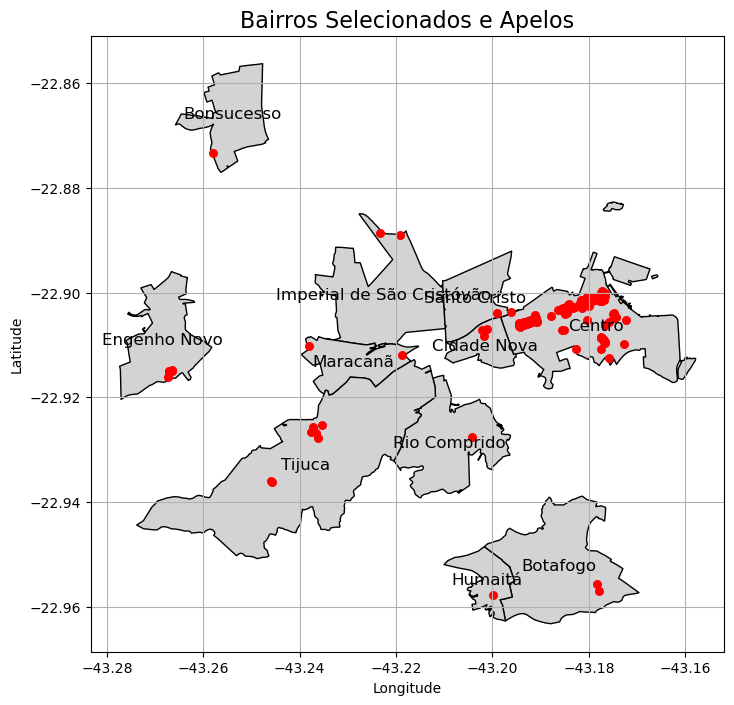

In [18]:
# Create a plot showing selected neighborhoods (filtro_bairros) and apelos
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot selected neighborhoods with a light gray color
filtro_bairros.plot(ax=ax, color='lightgray', edgecolor='black', legend=True)

# Get accurate centroids using the new function
centroids = geo.get_centroids(filtro_bairros)

# Add labels for each selected neighborhood
for label, x, y in zip(filtro_bairros.nome, centroids.x, centroids.y):
    ax.text(x, y, label, fontsize=12, ha='center', va='center')

# Plot apelos points
apelos.plot(ax=ax, color='red', markersize=30, marker='o', label='Apelos')

# Customize the plot
ax.set_title("Bairros Selecionados e Apelos", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True)

### Data Export <a name="export"></a>

In [19]:
# Save the filtered data to a new GeoJSON file with pretty formatting
geo.save_geojson_pretty(filtro_bairros, "processed_data/filtro_bairros_tese.geojson");

✅ Success! Saved pretty GeoJSON to 'processed_data/filtro_bairros_tese.geojson'
